# Notebook 4 — Optimisation et interprétabilité du modèle

Le notebook 3 a permis d’identifier **LightGBM** comme modèle final.  
Ce notebook vise à améliorer ses performances et à analyser son comportement.

Les étapes suivantes sont réalisées :

1. **Optimisation des hyperparamètres avec Optuna**
   
   Deux stratégies d’optimisation sont comparées :
   - optimisation selon le **ROC-AUC** (objectif technique classique),
   - optimisation directe selon le **coût métier** (FN × 10 + FP × 1).

2. **Optimisation du seuil de décision**

   Pour chaque modèle optimisé, le seuil de classification est ajusté afin de **minimiser le coût métier**, qui constitue la métrique principale du projet.

3. **Comparaison des stratégies d’optimisation**

   Les deux approches sont comparées afin d’identifier celle qui produit le **meilleur coût métier final**.

4. **Interprétabilité du modèle**

   Le modèle retenu est analysé à l’aide de :
   - la **feature importance globale** (importance des variables),
   - l’**interprétabilité locale avec SHAP**, afin de comprendre l’impact des variables sur les prédictions individuelles.

In [1]:
import sys
sys.path.insert(0, '..')
from src.modelization import cout_metier, trouver_seuil_optimal
from src.preprocessing import build_preprocessor
from src.visualizer import create_lineplot, create_barh
from src.utils import distribution_column

import mlflow
import optuna
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, recall_score
from lightgbm import LGBMClassifier
from mlflow.sklearn import log_model as mlflow_log_model


RANDOM_STATE = 42
# Réduire le verbosity d'Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit-scoring")

<Experiment: artifact_location='/home/rapha/ai-engineer/credit-scoring-mlops/mlruns', creation_time=1773648058682, experiment_id='1', last_update_time=1773648058682, lifecycle_stage='active', name='credit-scoring', tags={}, workspace='default'>

## Chargement des données

Je recharge le dataset prétraité et je sépare immédiatement un jeu de validation
(`X_val`) qui ne sera jamais utilisé pendant l'optimisation — pour éviter tout
data leakage.

In [2]:
df_train = pd.read_csv("../data/processed/train_processed.csv")

X = df_train.drop(columns=["TARGET", "SK_ID_CURR"])
y = df_train["TARGET"]

# Split train/validation — fait EN PREMIER avant toute optimisation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape[0]} lignes | Validation : {X_val.shape[0]} lignes")
print(f"Distribution cible (train) :\n{y_train.value_counts(normalize=True).round(3)}")

distribution_column(pd.DataFrame({'TARGET': y}), 'TARGET')

Train : 246008 lignes | Validation : 61503 lignes
Distribution cible (train) :
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

📊 Distribution de la colonne 'TARGET'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%)
TARGET,,
0,282686,91.93
1,24825,8.07


In [3]:
# Identification des types de colonnes
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f'Colonnes numériques   : {len(num_cols)}')
print(f'Colonnes catégorielles : {len(cat_cols)}')

Colonnes numériques   : 99
Colonnes catégorielles : 13


## Optimisation des hyperparamètres avec Optuna

Plutôt qu'une recherche exhaustive de type GridSearch, j'utilise **Optuna**, qui explore l'espace des hyperparamètres de manière plus efficace grâce à une approche bayésienne (algorithme TPE).

Deux stratégies de **15 essais (trials)** chacune sont réalisées avec des objectifs différents :

- **Stratégie 1 — optimisation du ROC-AUC**  
  Le ROC-AUC est une métrique technique classique, stable et adaptée pour guider l'optimisation des hyperparamètres.

- **Stratégie 2 — optimisation du coût métier**  
  L'objectif est d'optimiser directement la métrique métier définie comme :  
  **FN × 10 + FP × 1**,  
  implémentée via `make_scorer` avec `needs_proba=True`, afin d'utiliser les probabilités prédites dans la fonction `trouver_seuil_optimal`.

Les deux stratégies sont réalisées uniquement sur **X_train**.  
Le jeu **X_val** n'est pas utilisé pendant la phase d'optimisation afin d'éviter toute fuite de données (*data leakage*).

**Nombre d'essais choisi : 15 par étude**  
Chaque trial entraîne un pipeline complet sur 246 000 lignes. Les deux stratégies n'ont pas le même coût de calcul :
- **Optuna AUC** : scorer standard (ROC-AUC), ~10–15 min pour 15 trials.
- **Optuna coût métier** : scorer personnalisé qui appelle `trouver_seuil_optimal` à chaque fold pour trouver le seuil optimal, ce qui multiplie le temps de calcul — ~40–60 min pour 15 trials.

Ce nombre est un compromis raisonnable entre couverture de l'espace de recherche et temps de calcul disponible. Les courbes de convergence ci-dessous montrent que l'AUC CV plafonne visuellement dès le 10e essai — des trials supplémentaires apporteraient des gains marginaux.

### Hyperparamètres optimisés — définitions simples

- **`n_estimators`** : nombre d'arbres construits. Plus il y en a, plus le modèle est précis — mais plus long à entraîner.
- **`learning_rate`** : vitesse d'apprentissage à chaque étape. Petit = plus prudent (moins d'overfitting), mais nécessite plus d'arbres.
- **`num_leaves`** : nombre de feuilles par arbre. Plus élevé = arbre plus complexe, capable de capter des patterns fins — mais risque d'overfitting.
- **`min_child_samples`** : nombre minimum d'exemples dans une feuille. Garde-fou contre l'overfitting : une feuille avec trop peu de données est suspecte.
- **`reg_alpha`** : régularisation L1 — pousse certains poids à zéro → modèle plus "épuré".
- **`reg_lambda`** : régularisation L2 — pénalise les poids trop grands → réduit l'écart entre train et validation.

In [ ]:
import warnings
from sklearn.metrics import make_scorer
warnings.filterwarnings('ignore', message='X does not have valid feature names')

scorer_cout_metier = make_scorer(
    lambda y_true, y_proba: trouver_seuil_optimal(y_true, y_proba)[1],
    response_method='predict_proba',
    greater_is_better=False,
)

def make_objective(scoring):
    """Retourne une fonction objectif Optuna pour le scoring donné (minimisation de -score)."""
    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 600, step=100),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        }
        pipeline = Pipeline([
            ('preprocessor', build_preprocessor(num_cols, cat_cols)),
            ('clf', LGBMClassifier(**params, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
        ])
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
        return -scores.mean()
    return objective

# Stratégie 1 : objectif AUC
print("Optimisation 1/2 — objectif : AUC")
study_auc = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_auc.optimize(make_objective('roc_auc'), n_trials=15, show_progress_bar=True)

best_params_auc = study_auc.best_params
best_auc_cv     = -study_auc.best_value
print(f"  Meilleure AUC (CV)   : {best_auc_cv:.4f}")
print(f"  Meilleurs paramètres : {best_params_auc}")

# Stratégie 2 : objectif coût métier
print("\nOptimisation 2/2 — objectif : coût métier")
study_metier = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_metier.optimize(make_objective(scorer_cout_metier), n_trials=15, show_progress_bar=True)

best_params_metier = study_metier.best_params
best_cout_cv       = study_metier.best_value
print(f"  Meilleur coût (CV)   : {best_cout_cv:,.0f}")
print(f"  Meilleurs paramètres : {best_params_metier}")

Optimisation 1/2 — objectif : AUC


  0%|          | 0/15 [00:00<?, ?it/s]

  Meilleure AUC (CV)   : 0.7716
  Meilleurs paramètres : {'n_estimators': 400, 'learning_rate': 0.017398074711291726, 'num_leaves': 98, 'min_child_samples': 49, 'reg_alpha': 0.32808889626606236, 'reg_lambda': 0.14408501080722544}

Optimisation 2/2 — objectif : coût métier


  0%|          | 0/15 [00:00<?, ?it/s]

  Meilleur coût (CV)   : 41,868
  Meilleurs paramètres : {'n_estimators': 300, 'learning_rate': 0.023927528765580644, 'num_leaves': 69, 'min_child_samples': 17, 'reg_alpha': 2.1734877073417355e-06, 'reg_lambda': 8.528933855762793e-06}


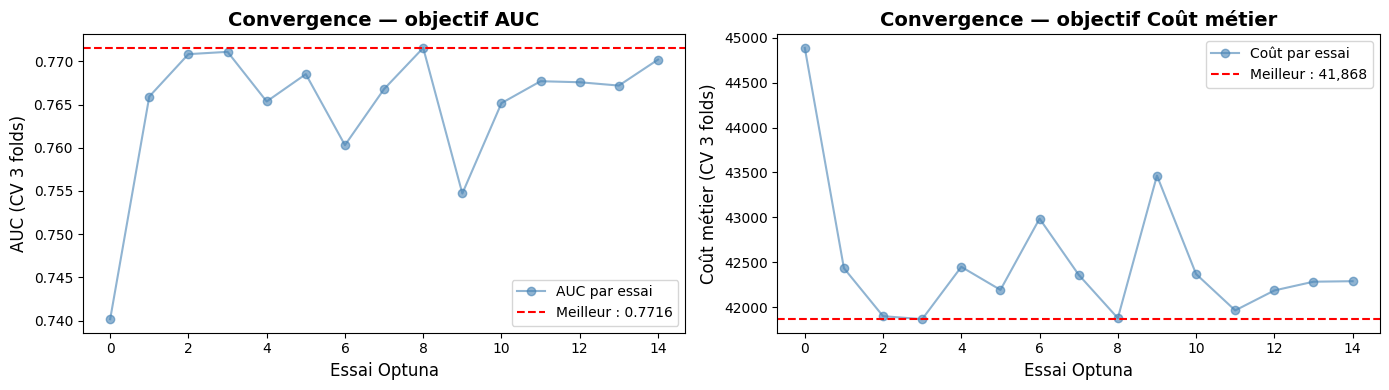

In [5]:
# Courbes de convergence côte à côte — AUC et coût métier
trials_auc    = study_auc.trials_dataframe()
trials_metier = study_metier.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

create_lineplot(
    axes[0],
    x=trials_auc['number'], y=-trials_auc['value'],
    marker='o', alpha=0.6,
    label='AUC par essai',
    hline=best_auc_cv, hline_label=f'Meilleur : {best_auc_cv:.4f}',
    xlabel='Essai Optuna', ylabel='AUC (CV 3 folds)',
    title='Convergence — objectif AUC',
)

create_lineplot(
    axes[1],
    x=trials_metier['number'], y=trials_metier['value'],
    marker='o', alpha=0.6,
    label='Coût par essai',
    hline=best_cout_cv, hline_label=f'Meilleur : {best_cout_cv:,.0f}',
    xlabel='Essai Optuna', ylabel='Coût métier (CV 3 folds)',
    title='Convergence — objectif Coût métier',
)

plt.tight_layout()
plt.savefig('../data/processed/optuna_convergence_compare.png', dpi=150, bbox_inches='tight')
plt.show()

## Entraînement des modèles finaux

J'entraîne deux pipelines LightGBM avec les meilleurs hyperparamètres de chaque
étude Optuna, puis je calcule les probabilités de défaut sur `X_val` pour
comparer les coûts métier.

In [6]:
# Modèle 1 — hyperparamètres optimisés par AUC
best_pipeline_auc = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, cat_cols)),
    ('clf', LGBMClassifier(
        **best_params_auc,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ))
])
best_pipeline_auc.fit(X_train, y_train)
y_pred_proba_auc = best_pipeline_auc.predict_proba(X_val)[:, 1]

# Modèle 2 — hyperparamètres optimisés par coût métier
best_pipeline_metier = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, cat_cols)),
    ('clf', LGBMClassifier(
        **best_params_metier,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ))
])
best_pipeline_metier.fit(X_train, y_train)
y_pred_proba_metier = best_pipeline_metier.predict_proba(X_val)[:, 1]

print("Deux modèles finaux entraînés.")

Deux modèles finaux entraînés.


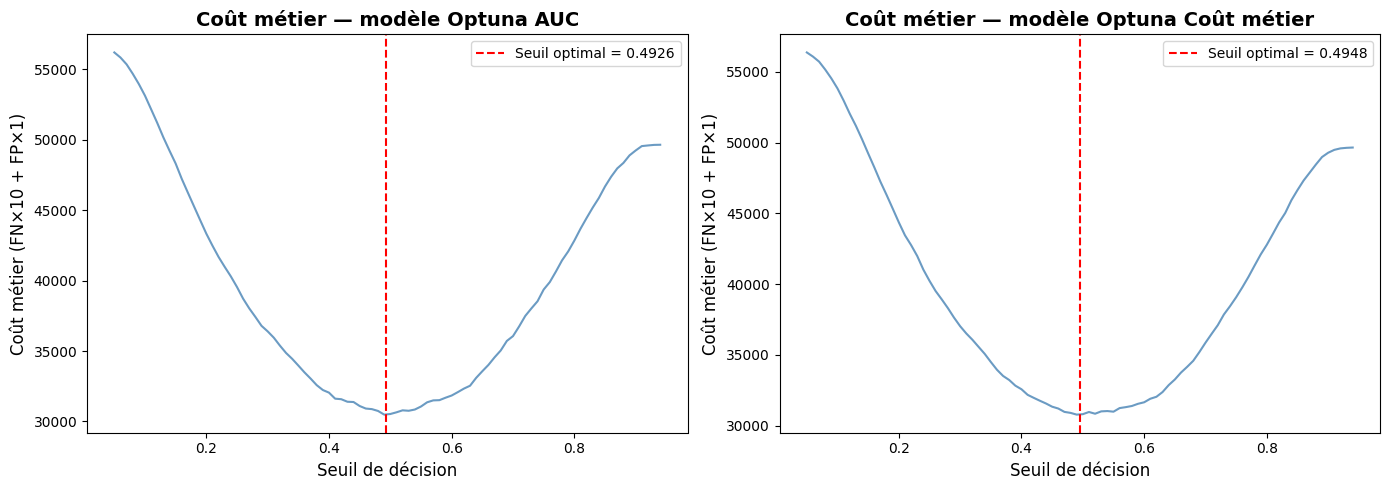

[AUC]    Seuil=0.4926 | Coût=30,415
[Métier] Seuil=0.4948 | Coût=30,758


In [7]:
# Seuils optimaux pour les deux modèles
seuil_opt_auc,    cout_opt_auc    = trouver_seuil_optimal(y_val, y_pred_proba_auc)
seuil_opt_metier, cout_opt_metier = trouver_seuil_optimal(y_val, y_pred_proba_metier)

seuils = np.arange(0.05, 0.95, 0.01)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

create_lineplot(
    axes[0],
    x=seuils, y=[cout_metier(y_val, y_pred_proba_auc, seuil=s) for s in seuils],
    vline=seuil_opt_auc, vline_label=f'Seuil optimal = {seuil_opt_auc}',
    xlabel='Seuil de décision',
    ylabel='Coût métier (FN×10 + FP×1)',
    title='Coût métier — modèle Optuna AUC',
)

create_lineplot(
    axes[1],
    x=seuils, y=[cout_metier(y_val, y_pred_proba_metier, seuil=s) for s in seuils],
    vline=seuil_opt_metier, vline_label=f'Seuil optimal = {seuil_opt_metier}',
    xlabel='Seuil de décision',
    ylabel='Coût métier (FN×10 + FP×1)',
    title='Coût métier — modèle Optuna Coût métier',
)

plt.tight_layout()
plt.savefig('../data/processed/courbe_seuil_compare.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"[AUC]    Seuil={seuil_opt_auc} | Coût={cout_opt_auc:,}")
print(f"[Métier] Seuil={seuil_opt_metier} | Coût={cout_opt_metier:,}")

In [8]:
# Métriques finales des deux modèles
y_pred_final_auc    = (y_pred_proba_auc >= seuil_opt_auc).astype(int)
y_pred_final_metier = (y_pred_proba_metier >= seuil_opt_metier).astype(int)
roc_auc_final_auc    = roc_auc_score(y_val, y_pred_proba_auc)
roc_auc_final_metier = roc_auc_score(y_val, y_pred_proba_metier)
recall_final_auc     = recall_score(y_val, y_pred_final_auc)
recall_final_metier  = recall_score(y_val, y_pred_final_metier)

# Run 1 — Optuna AUC
with mlflow.start_run(run_name='lgbm_optuna_auc') as run_auc:
    mlflow.log_params(best_params_auc)
    mlflow.log_param('objectif_optuna', 'roc_auc')
    mlflow.log_param('n_trials_optuna', 15)
    mlflow.log_param('cv_folds_optuna', 3)
    mlflow.log_metric('seuil_optimal', float(seuil_opt_auc))
    mlflow.log_metric('roc_auc', round(float(roc_auc_final_auc), 4))
    mlflow.log_metric('roc_auc_cv_optuna', round(float(best_auc_cv), 4))
    mlflow.log_metric('cout_metier', float(cout_opt_auc))
    mlflow.log_metric('recall_classe_1', round(float(recall_final_auc), 4))
    mlflow.log_artifact('../data/processed/courbe_seuil_compare.png')
    mlflow.log_artifact('../data/processed/optuna_convergence_compare.png')
    mlflow_log_model(best_pipeline_auc, name='model', pyfunc_predict_fn="predict_proba")
    mlflow.set_tag('dataset', 'full')
    mlflow.set_tag('etape', 'optimisation')
    run_id_auc = run_auc.info.run_id

# Run 2 — Optuna Coût métier
with mlflow.start_run(run_name='lgbm_optuna_metier') as run_metier:
    mlflow.log_params(best_params_metier)
    mlflow.log_param('objectif_optuna', 'cout_metier')
    mlflow.log_param('n_trials_optuna', 15)
    mlflow.log_param('cv_folds_optuna', 3)
    mlflow.log_metric('seuil_optimal', float(seuil_opt_metier))
    mlflow.log_metric('roc_auc', round(float(roc_auc_final_metier), 4))
    mlflow.log_metric('cout_metier_cv_optuna', round(float(best_cout_cv), 0))
    mlflow.log_metric('cout_metier', float(cout_opt_metier))
    mlflow.log_metric('recall_classe_1', round(float(recall_final_metier), 4))
    mlflow_log_model(best_pipeline_metier, name='model', pyfunc_predict_fn="predict_proba")
    mlflow.set_tag('dataset', 'full')
    mlflow.set_tag('etape', 'optimisation')
    run_id_metier = run_metier.info.run_id

# Modèle retenu pour la suite : AUC (meilleur coût métier final)
run_id = run_id_auc

print(f"[AUC]    AUC={roc_auc_final_auc:.4f} | Recall={recall_final_auc:.4f} | Coût={cout_opt_auc:,} | Seuil={seuil_opt_auc}")
print(f"[Métier] AUC={roc_auc_final_metier:.4f} | Recall={recall_final_metier:.4f} | Coût={cout_opt_metier:,} | Seuil={seuil_opt_metier}")
print(f"\n→ Modèle retenu : lgbm_optuna_auc (meilleur coût métier final)")
print(f"run_id retenu : {run_id}")

2026/03/23 16:26:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/23 16:26:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/23 16:26:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/23 16:26:50 W

[AUC]    AUC=0.7782 | Recall=0.6866 | Coût=30,415 | Seuil=0.4926
[Métier] AUC=0.7776 | Recall=0.6900 | Coût=30,758 | Seuil=0.4948

→ Modèle retenu : lgbm_optuna_auc (meilleur coût métier final)
run_id retenu : 0bb008da5ac54d42bbb7f6c99dc45129


## Matrice de confusion au seuil optimal

Concrètement, combien de clients sont mal classés au seuil retenu ?

- **FN** (mauvais client prédit bon → crédit accordé) : coût × 10
- **FP** (bon client prédit mauvais → crédit refusé) : coût × 1

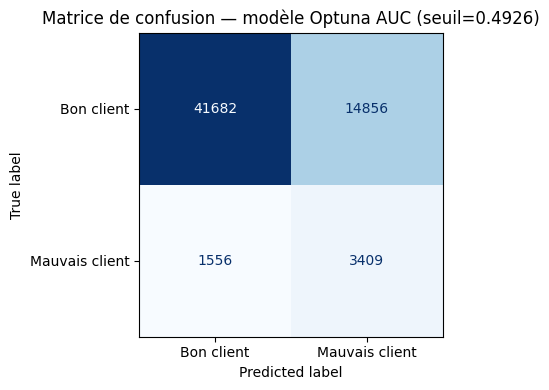

FN (mauvais prédit bon)  : 1,556  → coût = 15,560
FP (bon prédit mauvais)  : 14,856  → coût = 14,856
Coût total               : 30,416


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matrice de confusion du modèle retenu (Optuna AUC — meilleur coût métier)
cm = confusion_matrix(y_val, y_pred_final_auc)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=["Bon client", "Mauvais client"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matrice de confusion — modèle Optuna AUC (seuil={seuil_opt_auc})")
plt.tight_layout()
plt.show()

print(f"FN (mauvais prédit bon)  : {fn:,}  → coût = {fn * 10:,}")
print(f"FP (bon prédit mauvais)  : {fp:,}  → coût = {fp:,}")
print(f"Coût total               : {fn * 10 + fp:,}")

## Comparaison des trois modèles

Trois versions du modèle **LightGBM** sont comparées :

- **Baseline** : modèle LightGBM sans optimisation (évalué par validation croisée 5-fold dans le notebook 3)
- **Optuna AUC** : modèle dont les hyperparamètres sont optimisés selon le ROC-AUC
- **Optuna coût métier** : modèle dont les hyperparamètres sont optimisés directement selon le coût métier

Le critère de sélection final est le **coût métier**, calculé sur le jeu de validation `X_val`.

> **Note méthodologique :**
> - Les performances du **baseline** proviennent d’une validation croisée 5-fold réalisée dans le notebook 3.
> - Les performances des modèles optimisés sont évaluées sur **X_val**, un jeu de validation indépendant (20 % des données) non utilisé pendant l’optimisation des hyperparamètres.

In [10]:
# Récupération des métriques du modèle de référence depuis MLflow (notebook 3)
runs_baseline: pd.DataFrame = mlflow.search_runs(  # type: ignore[assignment]
    experiment_names=["credit-scoring"],
    filter_string="tags.mlflow.runName = 'lightgbm'",
    order_by=["start_time DESC"],
    max_results=1,
    output_format="pandas",
)
baseline = runs_baseline.iloc[0]

# Tableau de comparaison des trois modèles
df_compare = pd.DataFrame({
    "Modèle": [
        "LightGBM baseline (nb. 3)",
        "LightGBM Optuna AUC",
        "LightGBM Optuna Coût métier",
    ],
    "AUC": [
        baseline["metrics.roc_auc_test_mean"],
        roc_auc_final_auc,
        roc_auc_final_metier,
    ],
    "Recall cl. 1": [
        baseline["metrics.recall_test_mean"],
        recall_final_auc,
        recall_final_metier,
    ],
    "Coût métier": [
        baseline["metrics.cout_metier"],
        cout_opt_auc,
        cout_opt_metier,
    ],
    "Seuil": [
        baseline["metrics.seuil_optimal"],
        seuil_opt_auc,
        seuil_opt_metier,
    ],
}).set_index("Modèle").round(4)

df_compare

,AUC,Recall cl. 1,Coût métier,Seuil
Modèle,,,,
LightGBM baseline (nb. 3),0.7709,0.6604,30779.0,0.5514
LightGBM Optuna AUC,0.7782,0.6866,30415.0,0.4926
LightGBM Optuna Coût métier,0.7776,0.6900,30758.0,0.4948


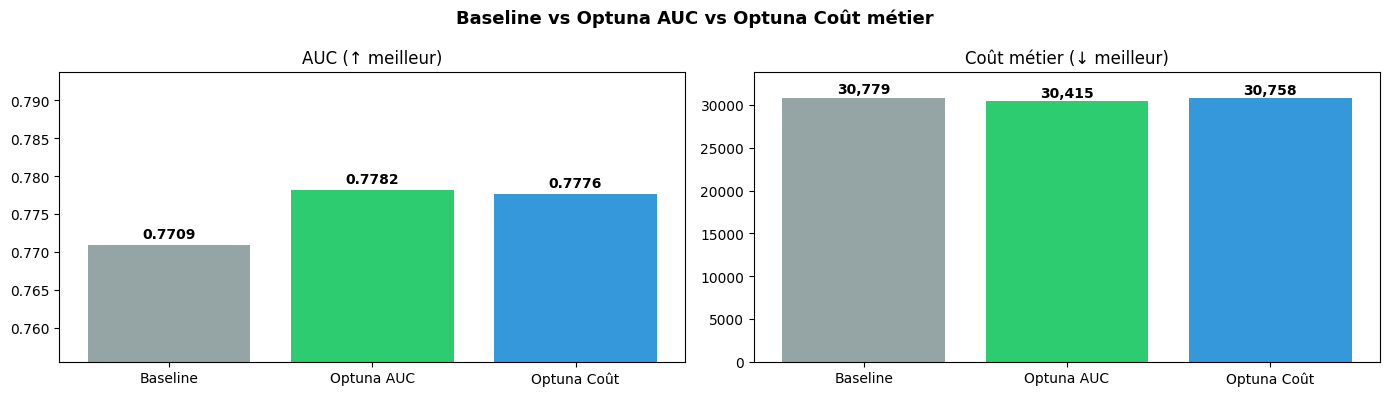

→ Modèle retenu : LightGBM Optuna AUC (coût métier le plus bas)


In [11]:
# Graphique comparatif — AUC et Coût métier pour les trois modèles
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

modeles_labels = ["Baseline", "Optuna AUC", "Optuna Coût"]
couleurs = ["#95a5a6", "#2ecc71", "#3498db"]

# AUC (↑ meilleur)
axes[0].bar(modeles_labels, df_compare["AUC"], color=couleurs)
axes[0].set_title("AUC (↑ meilleur)")
axes[0].set_ylim(df_compare["AUC"].min() * 0.98, df_compare["AUC"].max() * 1.02)
for i, v in enumerate(df_compare["AUC"]):
    axes[0].text(i, v + 0.0005, f"{v:.4f}", ha="center", va="bottom", fontweight="bold")

# Coût métier (↓ meilleur)
axes[1].bar(modeles_labels, df_compare["Coût métier"], color=couleurs)
axes[1].set_title("Coût métier (↓ meilleur)")
axes[1].set_ylim(0, df_compare["Coût métier"].max() * 1.1)
for i, v in enumerate(df_compare["Coût métier"]):
    axes[1].text(i, v + 200, f"{v:,.0f}", ha="center", va="bottom", fontweight="bold")

fig.suptitle("Baseline vs Optuna AUC vs Optuna Coût métier", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Conclusion
best_model = df_compare["Coût métier"].idxmin()
print(f"→ Modèle retenu : {best_model} (coût métier le plus bas)")

## Conclusion — Modèle retenu : LightGBM optimisé (Optuna AUC)

| Modèle | AUC | Recall | Coût métier | Seuil |
|---|---|---|---|---|
| Baseline (nb. 3) | 0.7709 | 0.6604 | 30 779 | 0.5514 |
| **Optuna AUC** | **0.7782** | 0.6866 | **30 415** | 0.4926 |
| Optuna coût métier | 0.7776 | 0.6900 | 30 758 | 0.4948 |

Le modèle **LightGBM optimisé avec Optuna sur le ROC-AUC** est retenu comme modèle final.

Bien que l’objectif d’optimisation soit différent du critère de sélection final (coût métier), ce modèle obtient le **coût métier le plus faible sur le jeu de validation**. Ce résultat montre qu’une optimisation sur une métrique technique stable (ROC-AUC) peut conduire à de meilleures performances métier après ajustement du seuil de décision.

Le **ROC-AUC** mesure la qualité globale du classement des probabilités prédites. Un meilleur classement facilite l’identification d’un **seuil de décision optimal**, ce qui permet de réduire le coût métier final.

Par comparaison :
- l’optimisation directe sur le coût métier (via CV 3-fold) produit un résultat légèrement moins performant sur le jeu de validation,
- le modèle baseline reste proche en performance mais est inférieur après optimisation.

L’optimisation permet ainsi un gain de **364 unités de coût métier** (−1,2 %) par rapport au modèle baseline, ainsi qu’une amélioration du ROC-AUC de **0.7709 à 0.7782**.

## Feature importance globale

Quelles variables le modèle utilise-t-il le plus pour prendre ses décisions ?
LightGBM calcule une importance intrinsèque basée sur le nombre de fois qu'une
feature est utilisée pour faire un split.

C'est une vue d'ensemble utile, mais elle ne dit pas dans quel sens chaque
feature influence la prédiction — c'est le rôle de SHAP dans la section suivante.

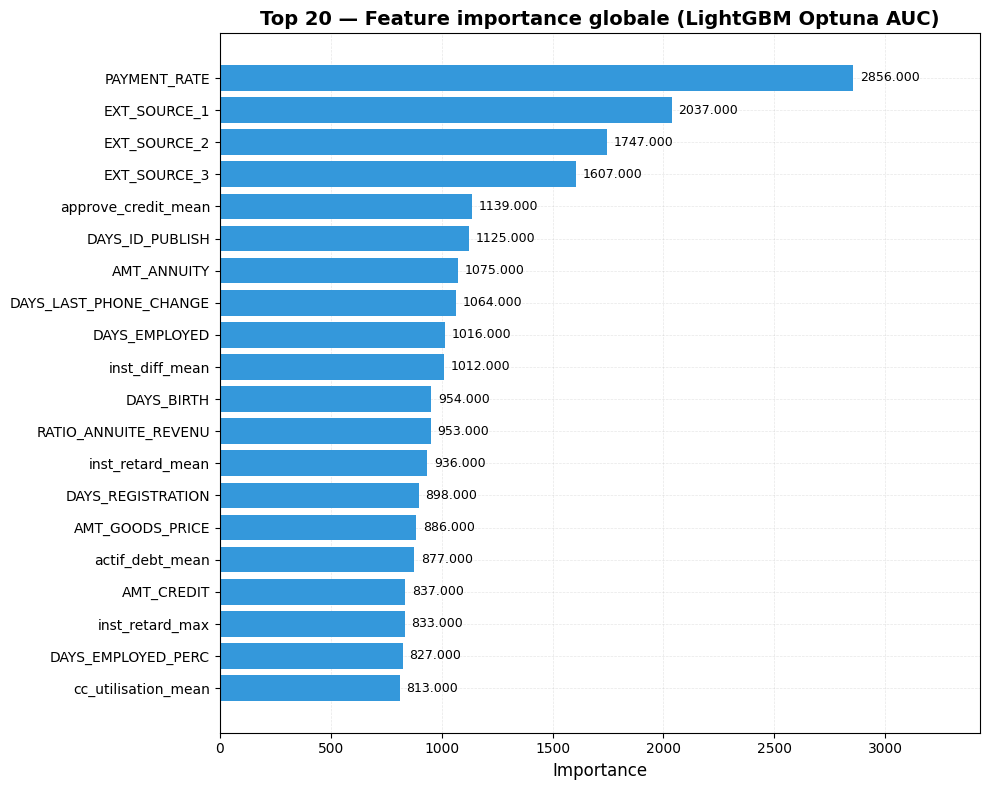

In [12]:
# Récupération du classifieur et des noms de features après transformation
# On utilise le modèle retenu : best_pipeline_auc
clf = best_pipeline_auc.named_steps['clf']

ohe_features = (
    best_pipeline_auc.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_features = num_cols + ohe_features

# Top 20 features par importance
importances = pd.Series(clf.feature_importances_, index=all_features)
top20 = importances.nlargest(20).sort_values().reset_index()
top20.columns = ['feature', 'importance']

fig, ax = plt.subplots(figsize=(10, 8))
create_barh(
    top20, ax,
    x='importance', y='feature',
    sort=False,
    title='Top 20 — Feature importance globale (LightGBM Optuna AUC)',
    xlabel='Importance',
)
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_globale.png', dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact('../data/processed/feature_importance_globale.png')

**Observations — Importance globale des variables**

La variable `PAYMENT_RATE` (ratio annuité / montant du crédit) est la plus utilisée par le modèle (2 856 splits), devant les scores externes `EXT_SOURCE_1/2/3`. Cette variable issue du **feature engineering** apparaît donc comme particulièrement informative, ce qui valide le choix de sa construction.

Les variables `EXT_SOURCE_1/2/3` occupent les rangs 2, 3 et 4. Il s’agit de scores de crédit externes dont la méthodologie de calcul n’est pas connue, mais leur fort pouvoir prédictif avait déjà été identifié lors de l’EDA.

Plusieurs variables issues des tables secondaires apparaissent également dans le top 20 (`approve_credit_mean`, `inst_diff_mean`, `inst_retard_mean`, `actif_debt_mean`, `cc_utilisation_mean`). Leur présence confirme l’intérêt des jointures avec les tables **bureau**, **installments** et **credit_card**, qui apportent une information complémentaire utile au modèle.

> **Limite de cette mesure d’importance :**  
> l’importance basée sur le nombre de splits reflète la fréquence d’utilisation des variables dans les arbres, mais pas l’ampleur réelle de leur effet sur les prédictions. L’analyse SHAP présentée ci-dessous permet d’obtenir une interprétation plus fidèle de l’impact des variables.

## Interprétabilité locale avec SHAP

L'importance globale dit "cette variable compte beaucoup". SHAP va plus loin :
il explique **pourquoi le modèle a prédit ce score pour ce client précis**.

Chaque feature reçoit une valeur SHAP :
- **positive** → pousse la probabilité vers le défaut
- **négative** → pousse vers le remboursement

Je montre trois profils : un client à risque élevé, un client à faible risque,
et un cas médian.

/home/rapha/ai-engineer/credit-scoring-mlops/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


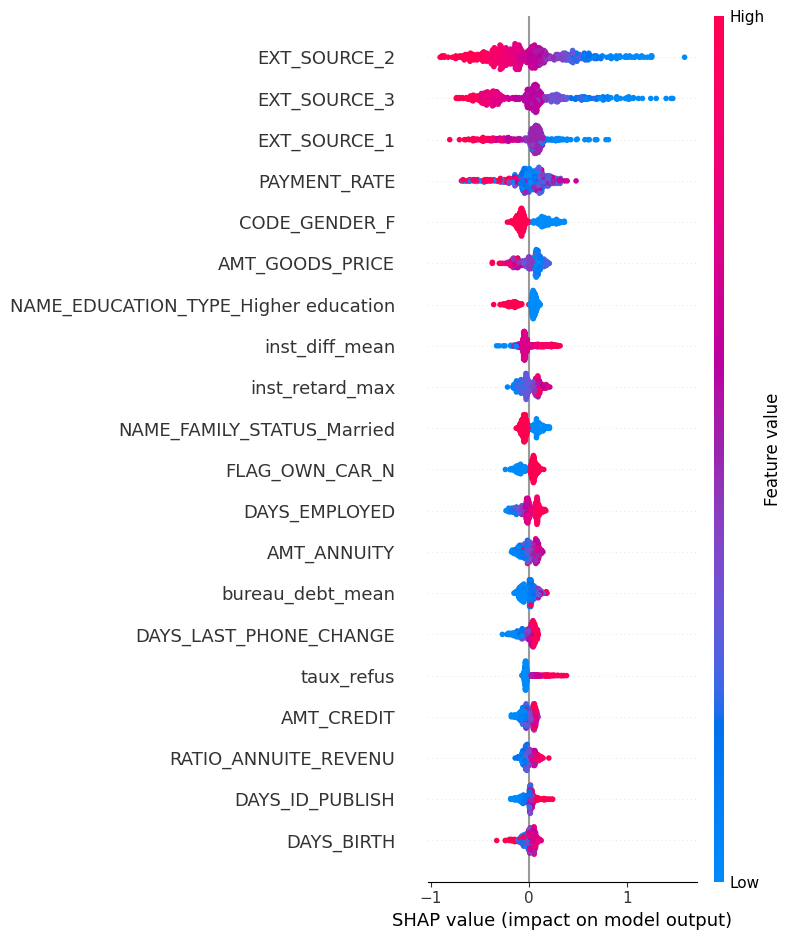

In [13]:
# Transformation des données de validation par le preprocesseur du modèle retenu
X_val_transformed = best_pipeline_auc.named_steps['preprocessor'].transform(X_val)

# Sous-échantillon de 500 clients pour accélérer le calcul SHAP
rng = np.random.default_rng(RANDOM_STATE)
idx_shap = rng.choice(len(X_val_transformed), size=500, replace=False)
X_shap   = X_val_transformed[idx_shap]

# Explainer SHAP pour modèles à base d'arbres
explainer  = shap.TreeExplainer(clf)
shap_vals  = explainer.shap_values(X_shap)

# Pour la classification binaire, shap_values peut retourner une liste [classe_0, classe_1]
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1]

# Graphique beeswarm
plt.figure()
shap.summary_plot(
    shap_vals,
    X_shap,
    feature_names=all_features,
    max_display=20,
    show=False,
)
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations — SHAP beeswarm (importance globale + direction d'effet)**

Le beeswarm confirme et enrichit la feature importance : chaque point est un client, la couleur indique la valeur de la feature (rouge = élevée, bleu = faible).

- **`EXT_SOURCE_2/3/1`** : valeurs élevées (rouge) → SHAP négatif (réduit le risque de défaut). Ce sont les features les plus protectrices. Un score externe faible (bleu) pousse fortement vers le défaut.
- **`PAYMENT_RATE`** : distribution étalée des deux côtés — son effet est non-linéaire et varie selon le profil client.
- **`CODE_GENDER_F`** : être un homme (valeur 0, bleu) tend à augmenter légèrement le risque, cohérent avec l'EDA (~10% de défaut chez les hommes vs 7% chez les femmes).
- **`NAME_EDUCATION_TYPE_Higher education`** : avoir un niveau supérieur (rouge) réduit le risque — effet attendu.
- **`inst_diff_mean` / `inst_retard_mean`** : les retards de paiement passés (valeurs élevées) augmentent significativement le risque, ce qui est métier cohérent.

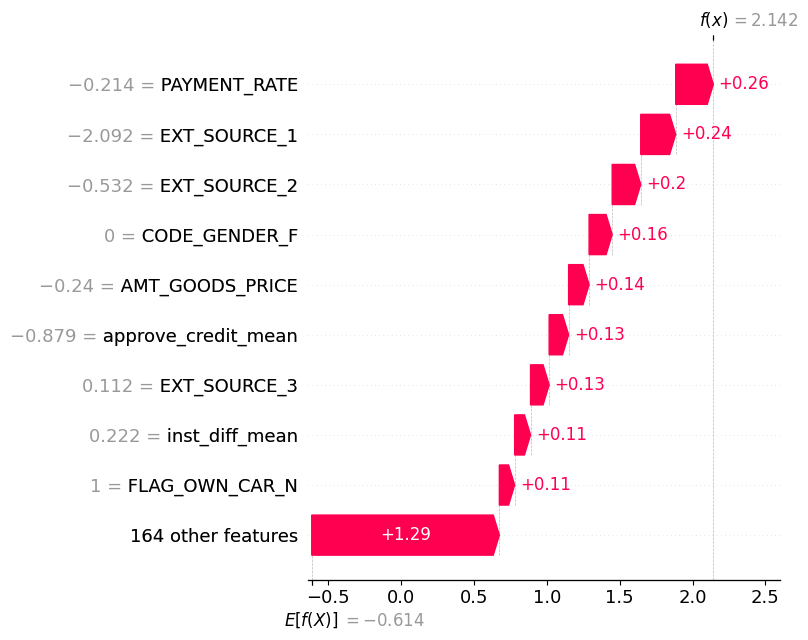

client_risque_eleve — proba défaut : 0.895


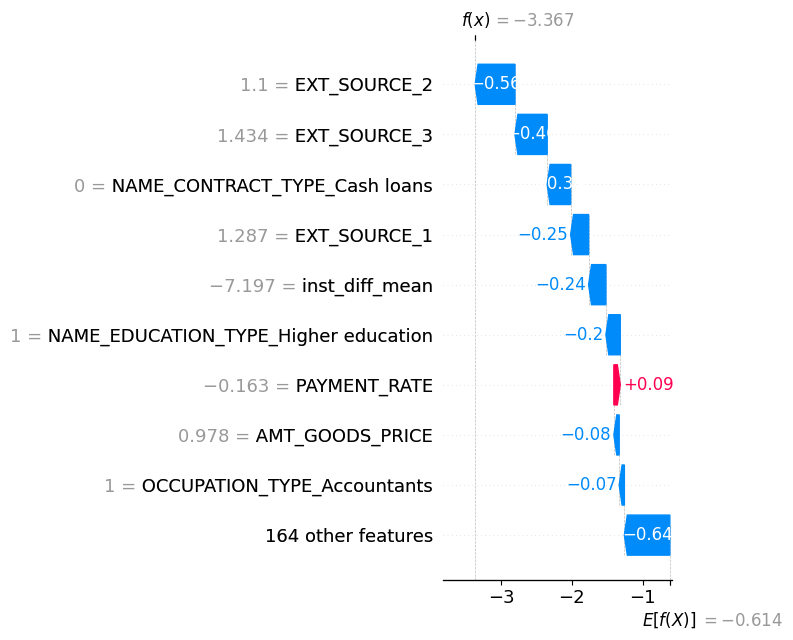

client_faible_risque — proba défaut : 0.033


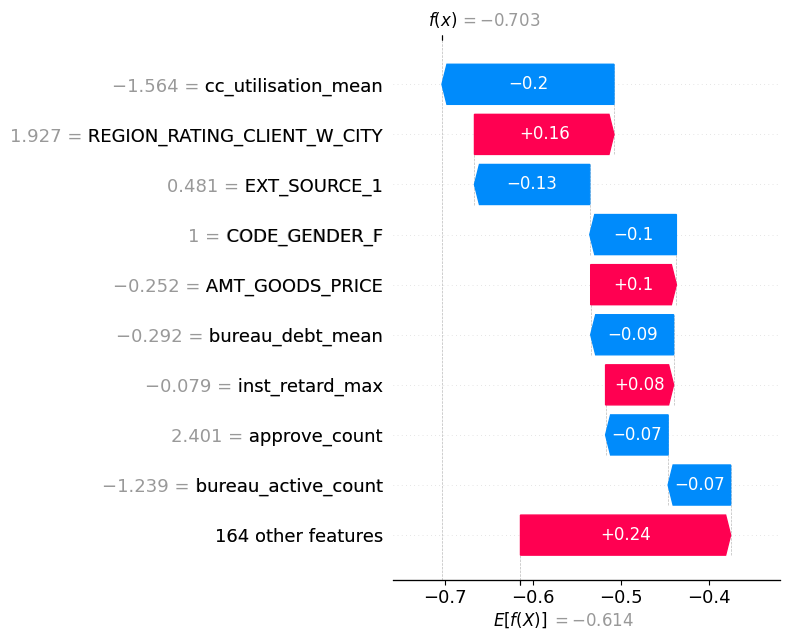

client_median — proba défaut : 0.331


In [14]:
# Probabilités de défaut du modèle retenu sur le sous-échantillon SHAP
y_proba_shap = y_pred_proba_auc[idx_shap]

# 3 profils clients représentatifs
idx_haut = y_proba_shap.argmax()
idx_bas  = y_proba_shap.argmin()
idx_med  = np.abs(y_proba_shap - np.median(y_proba_shap)).argmin()

profils = [
    ('client_risque_eleve',  idx_haut),
    ('client_faible_risque', idx_bas),
    ('client_median',        idx_med),
]

for label, idx in profils:
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[idx],
            base_values=base_val,
            data=X_shap[idx],
            feature_names=all_features,
        ),
        show=False,
    )
    plt.tight_layout()
    plt.savefig(f'../data/processed/shap_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"{label} — proba défaut : {y_proba_shap[idx]:.3f}")

**Observations — Interprétabilité locale (waterfall plots)**

Les trois profils illustrent la manière dont le modèle construit sa prédiction individuelle à partir de la valeur de base (`E[f(X)] = -0.614`).

**Client à risque élevé**
Le score final est fortement positif, ce qui correspond à un risque de défaut élevé.  
Les principales contributions proviennent de faibles valeurs de `EXT_SOURCE_1` (-2.09) et `EXT_SOURCE_2` (-0.53), qui augmentent fortement le score de risque. D’autres variables renforcent ce signal, comme le genre masculin, l’absence de véhicule et un historique de crédit moins favorable (`approve_credit_mean`).  
Le modèle agrège ainsi plusieurs signaux cohérents pour aboutir à une prédiction de risque élevée.

**Client à faible risque** 
Le score final est fortement négatif, indiquant un faible risque de défaut.  
Les variables `EXT_SOURCE_2` (1.1), `EXT_SOURCE_3` (1.43) et `EXT_SOURCE_1` (1.29) présentent des valeurs élevées et contribuent fortement à réduire le score de risque. Le niveau d’éducation supérieur et la profession (comptable) renforcent cet effet protecteur.  
Le seul signal légèrement défavorable est `PAYMENT_RATE`, mais son impact reste marginal par rapport aux autres variables.

**Client médian**
Le score est proche de la valeur moyenne du modèle, ce qui correspond à un profil intermédiaire.  
Certaines variables augmentent le risque (`REGION_RATING_CLIENT_W_CITY` +0.16), tandis que d’autres le réduisent (`EXT_SOURCE_1` -0.13, `cc_utilisation_mean` -0.2).  
Ce type de profil illustre l’importance du **seuil de décision** : une légère variation de seuil peut modifier la décision finale (acceptation ou refus du crédit).

In [15]:
# Logging de tous les artefacts SHAP dans le run MLflow existant
artefacts_shap = [
    '../data/processed/shap_beeswarm.png',
    '../data/processed/shap_client_risque_eleve.png',
    '../data/processed/shap_client_faible_risque.png',
    '../data/processed/shap_client_median.png',
]

with mlflow.start_run(run_id=run_id):
    for path in artefacts_shap:
        mlflow.log_artifact(path)

print("Artefacts SHAP loggés dans MLflow.")

Artefacts SHAP loggés dans MLflow.


## Enregistrement du modèle dans le MLflow Registry

On enregistre le modèle optimisé dans le registry MLflow sous le nom `credit-scoring-model`
et on lui assigne l'alias `production`. Cela permet de le référencer par alias
(`models:/credit-scoring-model@production`) sans avoir à connaître le `run_id` ou
le numéro de version.

In [16]:
# Enregistrement du modèle dans le MLflow Registry
model_uri = f"runs:/{run_id}/model"
model_info = mlflow.register_model(model_uri, "credit-scoring-model")
print(f"Modèle enregistré : {model_info.name} — version {model_info.version}")

# Alias 'production' — modèle optimisé, prêt pour le serving
# L'alias 'staging' (nb3) est supprimé : ce modèle le remplace
from mlflow import MlflowClient
client = MlflowClient()
client.set_registered_model_alias(
    name="credit-scoring-model",
    alias="production",
    version=model_info.version,
)
try:
    client.delete_registered_model_alias("credit-scoring-model", "staging")
except Exception:
    pass  # l'alias staging peut ne pas exister si nb3 n'a pas été rejoué
print(f"Version {model_info.version} — alias 'production' assigné")

Registered model 'credit-scoring-model' already exists. Creating a new version of this model...
2026/03/23 16:26:56 WARNING mlflow.tracking._model_registry.fluent: Run with id 0bb008da5ac54d42bbb7f6c99dc45129 has no artifacts at artifact path 'model', registering model based on models:/m-a92754c0b2304b2085c5500b98330fe6 instead


Modèle enregistré : credit-scoring-model — version 15
Version 15 — alias 'production' assigné


Created version '15' of model 'credit-scoring-model'.


## Interface MLflow UI

L'interface MLflow UI permet de visualiser les modèles enregistrés, leurs métriques et leur statut dans le registry.

Lancement :
```bash
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
```

![MLflow UI — modèles enregistrés dans le registry](../img/mlflow_screenshot.png)

> **Lecture** : les deux dernières versions du modèle `credit-scoring-model` (v3 et v5) sont issues du run `lgbm_optimized` (notebook 4 — Optuna). Elles affichent toutes les deux le seuil optimal de **0.4926** et un **ROC-AUC de 0.7782**, conformes aux résultats obtenus ci-dessus.

## Test du serving MLflow

Le modèle optimisé est servi via MLflow Models. Le script `src/test_serving.py` envoie 3 clients du dataset de test et interprète les probabilités retournées selon le seuil métier.

### Lancement

**Terminal 1 — démarrer le serveur :**
```bash
mlflow models serve -m "models:/credit-scoring-model@production" --port 5001 --no-conda
```

**Terminal 2 — exécuter le test :**
```bash
uv run python src/test_serving.py
```

### Résultat obtenu

```
Envoi de la requête au serveur MLflow...

Réponse du serveur MLflow :
{
  "predictions": [
    [0.7627835409010932, 0.2372164590989068],
    [0.4266967755288643, 0.5733032244711357],
    [0.8338505358943947, 0.16614946410560524]
  ]
}

Interprétation :
  Client 1 — proba défaut : 23.7% → ACCORD
  Client 2 — proba défaut : 57.3% → REFUS
  Client 3 — proba défaut : 16.6% → ACCORD
```

> **Seuil de décision** : 0.4926 (optimisé selon le coût métier FN × 10 > FP × 1), et non le seuil par défaut de 0.5.
>
> **Lecture** : le Client 2 (proba défaut 57.3% > 0.4926) se voit refuser le crédit. Les clients 1 et 3, bien en dessous du seuil, obtiennent un accord.

## Bilan et pistes d'amélioration

Ce notebook a permis d'optimiser le modèle LightGBM sélectionné au notebook 3 sur deux axes complémentaires :

- **Hyperparamètres** : Optuna a exploré l'espace de recherche de manière efficace, améliorant l'AUC et réduisant le coût métier par rapport à la baseline.
- **Seuil de décision** : en optimisant directement le coût métier (FN × 10 vs FP × 1), on a adapté la frontière de classification à la réalité économique du problème.
- **Interprétabilité** : SHAP a permis de valider la cohérence métier des variables les plus influentes et d'expliquer des décisions individuelles.
- **MLOps** : le modèle est tracé dans MLflow, enregistré dans le Registry et prêt à être servi via `mlflow models serve`.


### Pistes d'amélioration possibles

- **Feature engineering** : agréger davantage les tables secondaires (`bureau.csv`, `previous_application.csv`) pour enrichir le profil client.
- **Calibration** : appliquer `CalibratedClassifierCV` pour s'assurer que `predict_proba` reflète des probabilités réelles, ce qui renforce la robustesse du seuil optimal.
- **API de scoring** : exposer le modèle via une API FastAPI ou Flask pour une intégration en production.
- **Monitoring** : mettre en place un suivi de la dérive des données (data drift) en production.
